In [ ]:
# SL - Regression - SL, MLR, PR, L1, L2
# Machine Learning 
# -> Supervised Learning - data we have labels  
# -> Classification
# -> model is trained to predict the class label of a given input data
# -> class A, class B, class C
# -> machine learn with data -> predict -> new data that is entered -> which class ?

# 1. Binary Classification :
# -> most simple, model predicts one of the two possible outcomes
# -> gmail -> mails - spam or not spam
# -> ALgorithms - Logistic Regression, Naive Bayes, KNN, SVM, Decision Trees

# 2. Multiclass Classification :
# -> 3 or more classes 
# gmail -> mails - spam, primary, promotional

# 3. Multilabel Classification :
# -> data may belong to multiple labels
# -> article -> Politics, Finance

# 4. Imbalanced Classification :
# -> data as imabalanced 
# -> any one class you have many rows, good number if inputs
# -> other class you have very few rows, lesser number of inputs
# -> bank transactions - most of data is non fraduelent transactions
# -> few rows are having fradulent transactions

In [ ]:
# 1. Binary Classification :
# -> Logistic Regression Algorithm
# -> SL technique - used for binary classification
# -> apply sigmoid function to the features
# -> probability value b/w 0 and 1
# -> class 0, class 1
# -> probability > 0.5 -> model predicted instance belongs to class 1 - give label as 1
# -> else case negative class - class 0
# -> breast cancer dataset -> Wisconsin 
# -> 30 numeric features -> tissue images
# -> target var - diagnosis -> M(Malignant), B(Benign) 


In [3]:
# Import Libararies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

In [5]:
# load the dataset
df = pd.read_csv('Breast_cancer_dataset.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
# explore dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [9]:
# Distribution of the target variable
df['diagnosis'].value_counts() # M , B , count how many M and how many B

diagnosis
B    357
M    212
Name: count, dtype: int64

In [11]:
# Remove unwanted column - id
df = df.drop(["id"],axis=1) # df = df.drop(["Unnamed: 32","id"],axis=1)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
# Transform diagnosis - categorical column - into numeric column
from sklearn.preprocessing import LabelEncoder 
# M = 1, B = 0
encoder = LabelEncoder()
df['diagnosis'] = encoder.fit_transform(df['diagnosis']) # use its method (inbuilt) fit_transform
df['diagnosis']

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int32

In [15]:
# Split the dataset into features and target
X = df.drop('diagnosis', axis=1) # taking all 30 columns and dropping diagnosis
y = df['diagnosis']

# Split the dataset into training and testing sets - 80 - 20 % ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# standardize the features - use StandardScaler - mean and std method
# apply the logistic regression  model to the dataset
# use scaler and then write step for LR
# Pipeline - streamline the process - multi steps - we can that in pipeline

# Define the pipeline for scaler and LR
pipeline = Pipeline([
           ('scaler' , StandardScaler()),
           ('log_reg', LogisticRegression(max_iter=10000, random_state=42))
])

pipeline.fit(X_train, y_train)


,steps,"[('scaler', ...), ('log_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [21]:
# prediction on training set and testing test

y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Predict probabilites on testing set
y_pred_test_prob = pipeline.predict_proba(X_test)[:,1]

results_df = pd.DataFrame({
    'Actual label' :  y_test,
    'Predicted Label' : y_pred_test,
    'Predicted Probability' : y_pred_test_prob
})
results_df.head()

,Actual label,Predicted Label,Predicted Probability
204,0,0,0.113590
70,1,1,0.999991
131,1,1,0.996921
431,0,0,0.000510
540,0,0,0.000061


In [23]:
# Cal testing and training accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Testing Accuracy : {test_accuracy}")
print(f"Training Accuracy : {train_accuracy}")

Testing Accuracy : 0.9736842105263158
Training Accuracy : 0.9868131868131869


In [27]:
# Naive Bayes CLassifier

# -> probabilistic classifier based on Bayes Theorem'
# -> called naive - bcoz it assumnes that input vars are independent of each other
# -> used algo for large datsets, can be used in binary or multiclass 
# -> use cases - text classification, sentiment analysis

# Mathematical Bayes Theorem
# Bayes' Theorem: Naive Bayes relies on Bayes' Theorem, which states
# P(A|B) = (P(B|A) * P(A)) / P(B)
# P(A), P(B) are the independent probabilities of A and B
# P(B|A) is the probability of B given A
# P(A|B) is the probability of A given B
# apply this on same breast cancer dataset

from sklearn.naive_bayes import GaussianNB

In [29]:
pipeline_nb = Pipeline([
           ('scaler' , StandardScaler()),
           ('nb', GaussianNB())
])

pipeline_nb.fit(X_train, y_train)


,steps,"[('scaler', ...), ('nb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,priors,None
,var_smoothing,1e-09


In [35]:
# prediction on testing and training
# probaility prediction as well
y_pred_train = pipeline_nb.predict(X_train)
y_pred_test = pipeline_nb.predict(X_test)

# Predict probabilites on testing set
y_pred_test_prob = pipeline_nb.predict_proba(X_test)[:,1]

results_df = pd.DataFrame({
    'Actual label' :  y_test,
    'Predicted Label' : y_pred_test,
    'Predicted Probability' : y_pred_test_prob
})
print(results_df.head())
# accuracy score
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Testing Accuracy : {test_accuracy}")
print(f"Training Accuracy : {train_accuracy}")

     Actual label  Predicted Label  Predicted Probability
204             0                0           1.349483e-09
70              1                1           1.000000e+00
131             1                1           1.000000e+00
431             0                0           9.801091e-12
540             0                0           8.102568e-15
Testing Accuracy : 0.9649122807017544
Training Accuracy : 0.9362637362637363


In [ ]:
# KNN - K Nearest Neighbors
# -> both regression and classification
# -> concept -> data points which are near to each other they belong to similar class
# -> after training phase 
# -> for predictions -> calulate the distance b/w input data point and all training points used
# -> make use of Euclidean distance - decide which category it belongs

# steps :
# -> load the training data
# -> choose the k value which represent number of nearest neighbors to consider
# -> 20 data points
# -> new one - cal distance
# -> k=3
# -> find 3 smallest distances - consider them as 3 neighbors
# -> class of 1st (A), class of 2nd (A), class of 3rd (B)
# -> new data points - predict class as A

# implement KNN on breast cancer dataset

In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pipeline_knn = Pipeline([
           ('scaler' , StandardScaler()),
           ('knn' , KNeighborsClassifier(n_neighbors=3)) # KNN Classifier
])

pipeline_knn.fit(X_train, y_train)

,steps,"[('scaler', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [39]:
# prediction on testing and training
# probaility prediction as well
y_pred_train = pipeline_knn.predict(X_train)
y_pred_test = pipeline_knn.predict(X_test)

# Predict probabilites on testing set
y_pred_test_prob = pipeline_knn.predict_proba(X_test)[:,1]

results_df = pd.DataFrame({
    'Actual label' :  y_test,
    'Predicted Label' : y_pred_test,
    'Predicted Probability' : y_pred_test_prob
})
print(results_df.head())
# accuracy score
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Testing Accuracy : {test_accuracy}")
print(f"Training Accuracy : {train_accuracy}")

     Actual label  Predicted Label  Predicted Probability
204             0                0                    0.0
70              1                1                    1.0
131             1                1                    1.0
431             0                0                    0.0
540             0                0                    0.0
Testing Accuracy : 0.9473684210526315
Training Accuracy : 0.9846153846153847


Confusion Matrix
[[68  3]
 [ 3 40]]


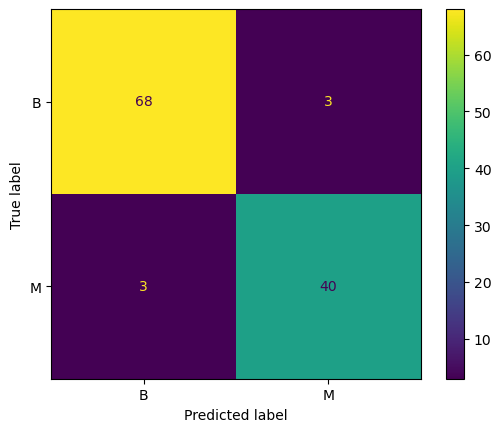

In [49]:
conf_matrix = confusion_matrix(y_test, y_pred_test)
print('Confusion Matrix')
print(conf_matrix)

cm_display =  ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ['B','M'])
cm_display.plot()
plt.show()

In [45]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
# Confusion Matrix 
# -> performance evaluation table fro classification models
# -> shows how well your model has predicted labels as per the actual labels
# -> number of how many correct predictions were there and how many wrong prerictions
Confusion Matrix
[[68  3]  - B  [TP FN]
 [ 3 40]] - M  [FP TN]

# TP (True Positive) - model predicted positive and actually it was positive
#                    - 68 out of 71 are predicted correctly
# FN (False Negative) - model predicted negative but actually it was positive
#                    - 3 out of 71 are predicted incorrectly
# FP (False Positive) - model predicted positive but it was actually negative
#                    - 3 out of 43 were predicted positive incorrectly
# TN (True Negative) - model predicted negative and actually also it was negative
#                    - 40 out of 43 were predicted negative correctly

In [ ]:
# classification_report
# -> gives a detailed summary of how well your classifier(KNN) perfoemed on data set
# -> generated from confusion matrix only
                precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

# precision P - measures how many of the predicted positive were actually positives
#           - how accurate are positive predictions
#           - TP / (TP + FP)
# should be high

# recall R - measures how many of the actual positives were correctly identified
#        - TP / (TP + FN)
# should be high

# f1-score - harmonic mean of precision and recall
#          - 2 * ( P * R  / P + R)
#          - balances both P and R
# more useful metric in case of imbalanced dataset 

# Support S
# total number of actual occurences in each class

# accuracy -> TP+TN / TP+TN+FP+FN - precentage of correct predictions
# macro avg ->   P(Class1) + P(class2) + .....  / n
# weighted avg -> sum(P(i)*S(i)) / sum(Si)

In [57]:
# KNN - n_neighbors = 3
# crucial paramter - called hyperparamter
# value of this parameter going to effect your results
# k=3 best value ?
# smaller k -> model sensitive to noise data
# larger k -> might include less neighbors

# GridSearchCV -> can be used to find optimal k
# -> k which give best results
# -> give some value range for k -> (1,21) -> test for k=1 to k=20

# Hyperparameter Tuning using GridSearchCV algorithm

from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {'knn__n_neighbors' : np.arange(1,21)}

# create pipeline
pipeline_knn = Pipeline([
           ('scaler' , StandardScaler()),
           ('knn' , KNeighborsClassifier()) # KNN Classifier
])

# Intialize GridSearchCV
grid_search = GridSearchCV(pipeline_knn, param_grid, cv=10, scoring='accuracy')

# fit the grid search cv to data
grid_search.fit(X_train, y_train)

# Get the best k value
optimal_k = grid_search.best_params_['knn__n_neighbors']
print(f"Optimal k value is : {optimal_k}")

# Get the best score
best_score = grid_search.best_score_
print(f"Best accuracy score is : {best_score}")

Optimal k value is : 7
Best accuracy score is : 0.9713526570048309


In [ ]:
# k=3 we have to take 3 neighbors
# N1, N2, N3
# binary classification A or B
# N1 - class A, N2 - class B, N3 - class A
# new data point - class A (2 data points of A)

     Actual label  Predicted Label  Predicted Probability
204             0                0                    0.0
70              1                1                    1.0
131             1                1                    1.0
431             0                0                    0.0
540             0                0                    0.0
Testing Accuracy : 0.9473684210526315
Training Accuracy : 1.0
Confusion Matrix
[[68  3]
 [ 3 40]]


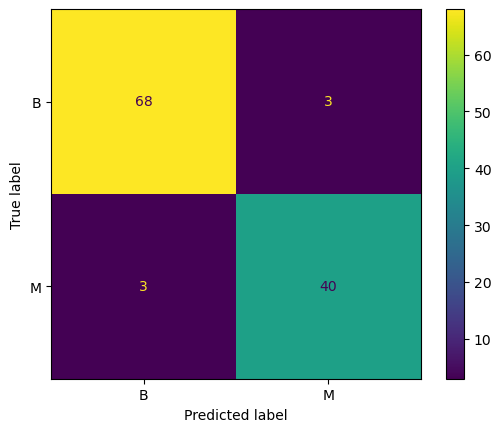

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [59]:
# Decision Tree 
# -> hierarchial tree structure 
# -> root node -> branches -> internal nodes -> leaf nodes

# -> how they work
# -> select the best attribute -> based on what attribute split the data
# -> split the dataset -> into subsets based on selected attribute
# -> repeat this process -> for each subset
# -> until some stopping condition is met - how much depth , all instacnes in a node belong to same class

from sklearn.tree import DecisionTreeClassifier
# create pipeline
pipeline_dt = Pipeline([
           ('scaler' , StandardScaler()),
           ('dt' , DecisionTreeClassifier()) # KNN Classifier
])
pipeline_dt.fit(X_train, y_train)
# Predict on training and testing
# calculate accuracy 
y_pred_train = pipeline_dt.predict(X_train)
y_pred_test = pipeline_dt.predict(X_test)
# Predict probabilites on testing set
y_pred_test_prob = pipeline_dt.predict_proba(X_test)[:,1]
results_df = pd.DataFrame({
    'Actual label' :  y_test,
    'Predicted Label' : y_pred_test,
    'Predicted Probability' : y_pred_test_prob
})
print(results_df.head())
# accuracy score
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Testing Accuracy : {test_accuracy}")
print(f"Training Accuracy : {train_accuracy}")
# calculate confusion matrix and classification report
conf_matrix = confusion_matrix(y_test, y_pred_test)
print('Confusion Matrix')
print(conf_matrix)
cm_display =  ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ['B','M'])
cm_display.plot()
plt.show()
print(classification_report(y_test, y_pred_test))

In [ ]:
# Decision Tree DT - problem - overfitting
# Overfitting -> model learns too much from training data
#             - give training data input -> very good accuracy
#             - new input, testing data -> acuuracy drops

# Resolve overfitting 
# - Pruning technique
# - some parts of DT that do not provide significant contribution in classifying, we can remove them
# - Pre-pruning (Early Stopping) 
#   -> halt the tree growth - based on max depth or min number of samples reqd to split
# - Post-pruning
#   -> first let tree grow fully and then remove nodes insignificant - reduce complexity

In [67]:
# Apply pruning technique for DT
# ccp_alpha - cost complexity paramter - controls the amount of pruning applied
# high value - then high pruning - many nodes will be removed
# when ccp_alpha = 0 -> no pruing is there
# when ccp_alpha is increased -> smaller tree, simpler tree
# ccp_alpha is too high -> tree becomes too shallow - this is called as underfitting
# 0.01, 0.1

pipeline_pruned_dt = Pipeline([
           ('scaler' , StandardScaler()),
           ('dt' , DecisionTreeClassifier(ccp_alpha=0.01, random_state=42)) 
])
pipeline_pruned_dt.fit(X_train, y_train)
# Predict on training and testing
# calculate accuracy 
y_pred_train = pipeline_pruned_dt.predict(X_train)
y_pred_test = pipeline_pruned_dt.predict(X_test)
# Predict probabilites on testing set
y_pred_test_prob = pipeline_pruned_dt.predict_proba(X_test)[:,1]
results_df = pd.DataFrame({
    'Actual label' :  y_test,
    'Predicted Label' : y_pred_test,
    'Predicted Probability' : y_pred_test_prob
})
print(results_df.head())
# accuracy score
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Testing Accuracy : {test_accuracy}")
print(f"Training Accuracy : {train_accuracy}")

     Actual label  Predicted Label  Predicted Probability
204             0                0               0.019011
70              1                1               0.985507
131             1                1               0.985507
431             0                0               0.019011
540             0                0               0.019011
Testing Accuracy : 0.956140350877193
Training Accuracy : 0.9802197802197802


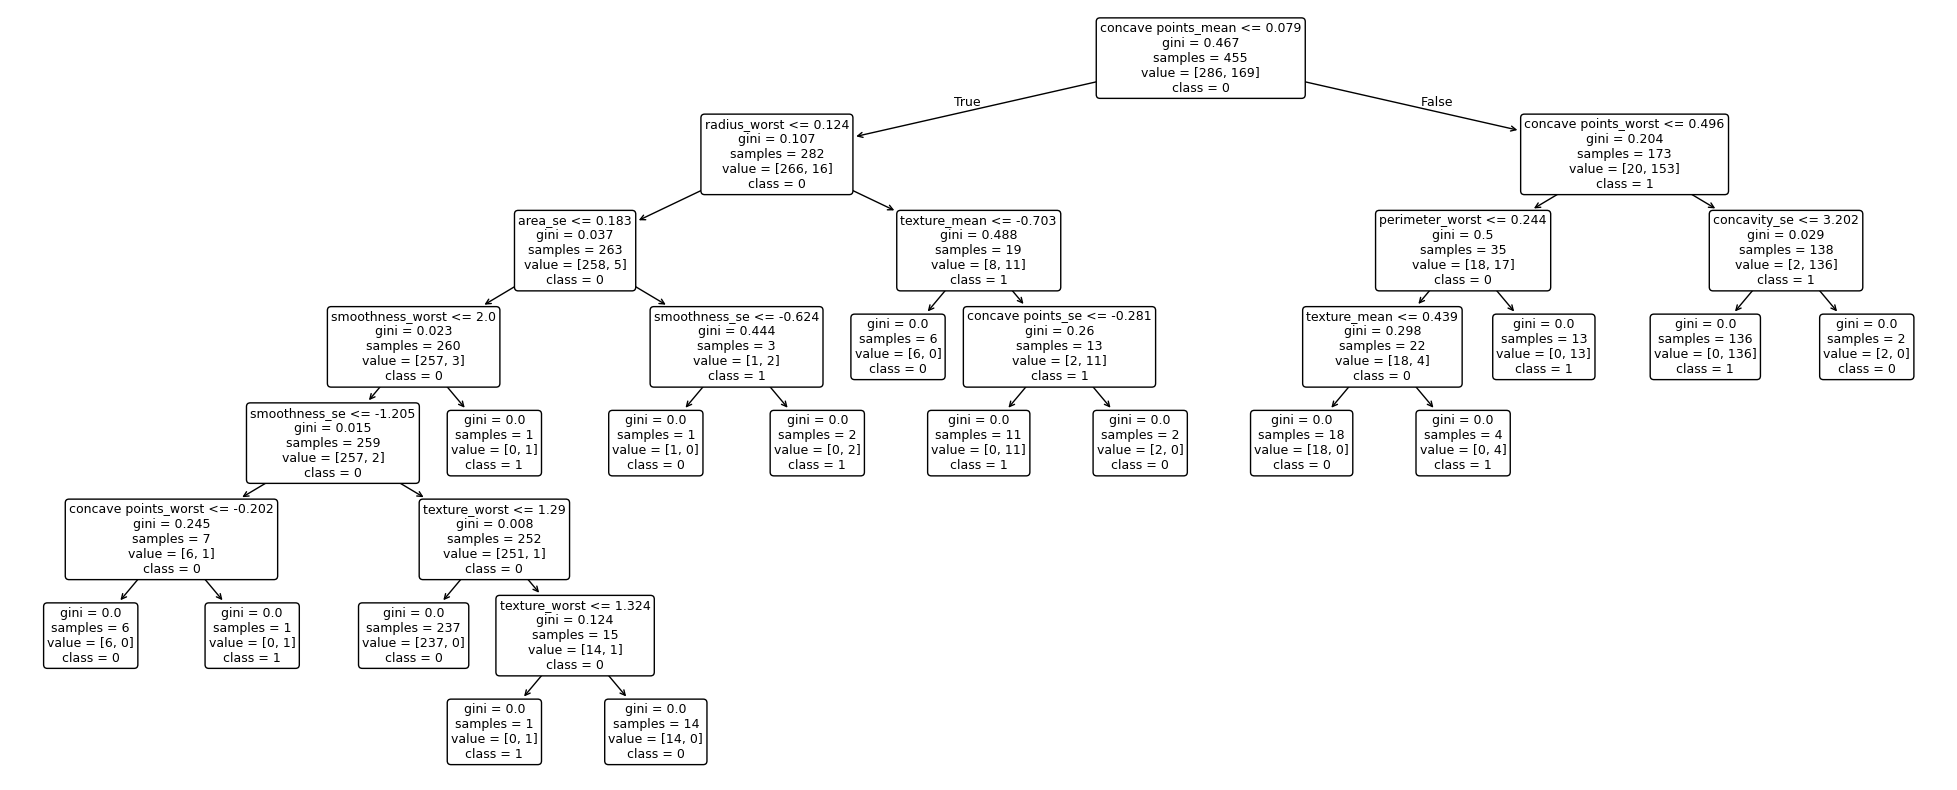

In [73]:
# Metrics for Splitting

# Gini Impurity : 
# -> measure of impurity or disorder in a set of elements 
# -> measures the likelihood of incorrectly classifying a randomly chosen element 
# -> ranges from 0 (perfect purity) to 0.5 ( max impurity)
# > p(i) as the probability of a data point being classified to class i
# -> Gini = 1 - sum (p(i)^2) 

# Entropy :
# -> tells the amount of uncertainity or impurity in the dataset
# -> p(i) 
# -> Entropy = - sum (p(i) * log p(i))

# Plot the tree

# Get the trained model from pipeline
from sklearn.tree import plot_tree

dt_model = pipeline_dt.named_steps['dt']

plt.figure(figsize=(25,10))
plot_tree(dt_model,
          feature_names = X_train.columns,
          class_names = [str(c) for c in dt_model.classes_],
          rounded = True,
          fontsize = 9)
plt.show()
          


In [75]:
# Hyperparamter Tuning in DT
# ccp_alpha
# max_depth -> max depth - number of splits from roof to leaf node
# min_samples_split -> minimum number of samples required to split a node
# min_samples_leaf -> min number of samples reqd to be at leaf node
# max_features -> number of features to consider when looking for best split
# GridSearchCV
pipeline_gs_dt = Pipeline([
           ('scaler' , StandardScaler()),
           ('dt' , DecisionTreeClassifier(random_state=42)) 
])
# define the paramter grid
param_grid = {
    'dt__max_depth' : [None, 10, 20, 30],
    'dt__min_samples_split' : [2, 5, 10],
    'dt__min_samples_leaf' : [1, 2, 4],
    'dt__max_features' : [None, 'sqrt', 'log2'],
    'dt__ccp_alpha' : [0.0, 0.01, 0.1]
}
# initiliaze grid search cv
grid_search = GridSearchCV(pipeline_gs_dt, param_grid, cv=5, scoring='accuracy')
# perform grid search
grid_search.fit(X_train, y_train)
# Fetch best params
print(f"Best Parameters : {grid_search.best_params_}")
# Predict with best paramters
y_pred_test = grid_search.best_estimator_.predict(X_test)
# Testing Accuracy
testing_acc = accuracy_score(y_test, y_pred_test)
print(f"Testing Accuracy : {testing_acc}")

Best Parameters : {'dt__ccp_alpha': 0.0, 'dt__max_depth': None, 'dt__max_features': 'log2', 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
Testing Accuracy : 0.956140350877193


In [ ]:
# SVM - Support Vector Machine
# -> classification and regression
# -> mainly used for classification
# In support vector machine, the required straight line to fit the data is called the hyperplane.
# The goal of the Support Vector Machine algorithm is to find a hyperplane in an n-dimensional space that distinctly classifies the data points.
# The closest data points to the hyperplane on either side are called Support Vectors.
# These support vectors influence the position and orientation of the hyperplane, aiding in the construction of the SVM.

     Actual label  Predicted Label  Predicted Probability
204             0                0               0.020564
70              1                1               1.000000
131             1                1               0.999992
431             0                0               0.000158
540             0                0               0.000062
Testing Accuracy : 0.9824561403508771
Training Accuracy : 0.989010989010989
Confusion Matrix
[[71  0]
 [ 2 41]]


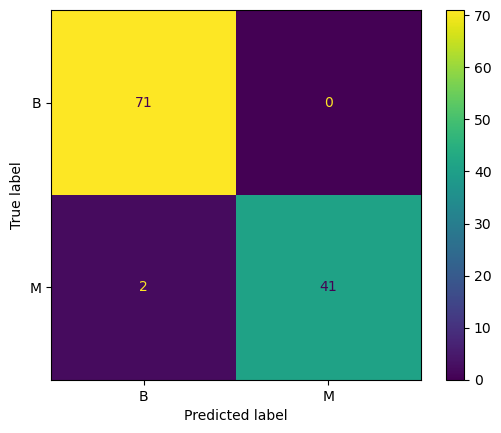

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [77]:
from sklearn.svm import SVC
# create pipeline
pipeline_svm = Pipeline([
           ('scaler' , StandardScaler()),
           ('svm' , SVC(probability=True, random_state=42)) 
])
pipeline_svm.fit(X_train, y_train)
# Predict on training and testing
# calculate accuracy 
y_pred_train = pipeline_svm.predict(X_train)
y_pred_test = pipeline_svm.predict(X_test)
# Predict probabilites on testing set
y_pred_test_prob = pipeline_svm.predict_proba(X_test)[:,1]
results_df = pd.DataFrame({
    'Actual label' :  y_test,
    'Predicted Label' : y_pred_test,
    'Predicted Probability' : y_pred_test_prob
})
print(results_df.head())
# accuracy score
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Testing Accuracy : {test_accuracy}")
print(f"Training Accuracy : {train_accuracy}")
# calculate confusion matrix and classification report
conf_matrix = confusion_matrix(y_test, y_pred_test)
print('Confusion Matrix')
print(conf_matrix)
cm_display =  ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ['B','M'])
cm_display.plot()
plt.show()
print(classification_report(y_test, y_pred_test))
